Baseline

In [1]:
import pandas as pd
df = pd.read_csv("../data/raw/creditcard.csv")

In [2]:
df = df.sample(n=50000, random_state=42)

In [ ]:
# 分层切分数据，保持训练/测试集的欺诈比例一致
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, precision_score, recall_score, f1_score


X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 用 Pipeline 把标准化和逻辑回归串起来，避免数据泄漏

# pipe = Pipeline([
#     ("scaler", StandardScaler()),
#     ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
# ])
# pipe.fit(X_train, y_train)

def train_lr(X_train, y_train, X_test, y_test):
    # 搭建流水线：标准化 + 逻辑回归
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ])
    pipe.fit(X_train, y_train)
    # 评估模型
    # model_evaluation(pipe, X_test, y_test)
    return pipe

def train_rf(X_train, y_train, X_test, y_test):
    # 树模型不需要标准化，直接训练
    pipe = Pipeline([
        ("clf", RandomForestClassifier(
            n_estimators=100,       # 决策树数量，可自行修改
            class_weight="balanced",# 适配不平衡样本
            random_state=42
        ))
    ])
    pipe.fit(X_train, y_train)
    # model_evaluation(pipe, X_test, y_test)
    return pipe

def train_xgb(X_train, y_train, X_test, y_test):
    pipe = Pipeline([
        ("clf", XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,      # 学习率，可自行调参
            scale_pos_weight=10,     # 不平衡样本权重，根据正负比例修改
            random_state=42,
            use_label_encoder=False,
            eval_metric="logloss"
        ))
    ])
    pipe.fit(X_train, y_train)
    # model_evaluation(pipe, X_test, y_test)
    return pipe


# 输出关键指标——因为样本极度不平衡，重点看 PR-AUC 和 Recall
# y_proba = pipe.predict_proba(X_test)[:, 1]
# print("ROC-AUC:", roc_auc_score(y_test, y_proba))
# print("PR-AUC :", average_precision_score(y_test, y_proba))
# print(classification_report(y_test, y_proba > 0.5))

# 终极升级版：包含全部核心指标（适配不平衡数据，取正类1的指标）
def evaluate(name, model, X_test, y_test):
    proba = model.predict_proba(X_test)[:, 1]
    y_pred = proba > 0.5

    return {
        "model": name,
        "ROC-AUC": round(roc_auc_score(y_test, proba), 4),
        "PR-AUC": round(average_precision_score(y_test, proba), 4),
        # 只统计少数类/正类=1的精准率、召回率、F1（不平衡数据核心指标）
        "Precision": round(precision_score(y_test, y_pred, pos_label=1), 4),
        "Recall": round(recall_score(y_test, y_pred, pos_label=1), 4),
        "F1-Score": round(f1_score(y_test, y_pred, pos_label=1), 4)
    }

# 批量存储结果
results = []

# 训练模型 + 录入指标
pipe_lr = train_lr(X_train, y_train, X_test, y_test)
results.append(evaluate("Logistic Regression", pipe_lr, X_test, y_test))

pipe_rf = train_rf(X_train, y_train, X_test, y_test)
results.append(evaluate("Random Forest", pipe_rf, X_test, y_test))

pipe_xgb = train_xgb(X_train, y_train, X_test, y_test)
results.append(evaluate("XGBoost", pipe_xgb, X_test, y_test))

# 生成完整对比表格
result_df = pd.DataFrame(results)
print("===== Comparison between 3 models =====")
print(result_df)


/Users/daisylu/miniconda3/envs/fin-risk/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


===== Comparison between 3 models =====
                 model  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
0  Logistic Regression   0.9282  0.6698     0.0531  0.7647    0.0992
1        Random Forest   0.8796  0.6817     0.8889  0.4706    0.6154
2              XGBoost   0.9795  0.7148     0.9231  0.7059    0.8000


In [ ]:
# 中文注释：定义业务成本，寻找最优阈值
import numpy as np
proba = pipe_xgb.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.01, 0.99, 99)
costs = []
for t in thresholds:
    y_pred = (proba > t).astype(int)
    fn = ((y_pred == 0) & (y_test == 1)).sum()  # 漏判欺诈
    fp = ((y_pred == 1) & (y_test == 0)).sum()  # 误报
    cost = 500 * fn + 5 * fp
    costs.append(cost)

best_t = thresholds[np.argmin(costs)]
print("Best thresholds:", best_t)

最优阈值: 0.02


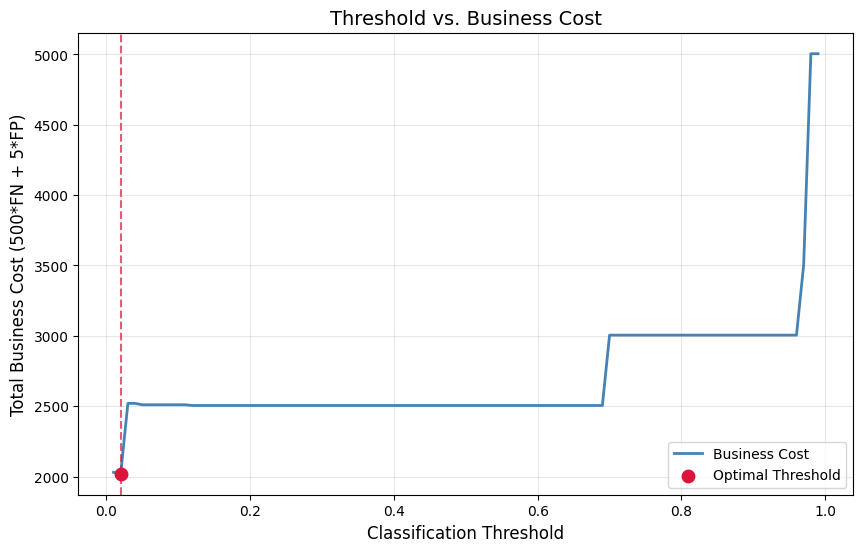

Best Threshold：0.0200
Minimized Cost：2020


In [11]:
# 绘制 阈值(x) - 业务成本(y) 曲线
plt.figure(figsize=(10, 6))
plt.plot(thresholds, costs, color="steelblue", linewidth=2, label="Business Cost")

# 标注最优阈值点（成本最低）
plt.scatter(best_t, min(costs), color="crimson", s=80, zorder=5, label="Optimal Threshold")

# 辅助线 + 标注文字
plt.axvline(x=best_t, color="crimson", linestyle="--", alpha=0.7)
plt.title("Threshold vs. Business Cost", fontsize=14)
plt.xlabel("Classification Threshold", fontsize=12)
plt.ylabel("Total Business Cost (500*FN + 5*FP)", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 打印最优结果
print(f"Best Threshold：{best_t:.4f}")
print(f"Minimized Cost：{min(costs)}")